1. Dissertação sobre o Problema
Descrição do Problema

O setor varejista opera com margens reduzidas e enfrenta desafios constantes na otimização de estoque, precificação de produtos e retenção de clientes. Sem um acompanhamento detalhado dos dados transacionais, supermercados correm riscos de rupturas de estoque de itens essenciais, sobreposição de produtos com baixa rotatividade e falta de previsibilidade do faturamento por país ou região.

* Importância e Relevância

Entender o comportamento do consumidor e os padrões de compra é crucial para a sustentabilidade financeira das empresas de varejo. Decisões baseadas em intuição levam a desperdícios de capital de giro e perdas operacionais em larga escala.

* Como a Análise de Dados Ajuda

Através do tratamento e exploração desses dados, é possível identificar os produtos mais vendidos por região, ticket médio por transação, frequência de compra por cliente e sazonalidade diária/mensal das vendas. Isso permite tomar decisões estratégicas de marketing, gestão de estoque e logística.

2. Fonte de Dados e Coleta de Informações

Nome do Dataset: Supermarket Dataset (Kaggle)

Origem: Repositório público de dados transacionais do Kaggle autor por Saurabh Badole.

Licença: MIT (Livre uso e modificação).

Tipos de Dados Disponíveis

Os dados são estruturados em formato tabular (CSV). As principais colunas são:

* Invoice: Identificador único da transação (Texto/Categorias).

* StockCode: Código do produto (Categorias/Texto).

* Description: Nome/descrição do item vendido (Texto não estruturado/Categorias).

* Quantity: Quantidade comprada do item (Numérico Inteiro).

* InvoiceDate: Data e hora da emissão da nota/compra (Data/Hora).

* Price: Preço unitário do produto (Numérico Decimal).

* Customer ID: Identificador único do cliente (Numérico/Identificador).

* Country: País de origem ou da transação (Texto/Categorias).

Método de Obtenção/Coleta

Forma de Download: Download direto do arquivo CSV do repositório via Kaggle.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# 1 Carregar o dataset
df = pd.read_csv('supermarket_data.csv', encoding='latin1')

In [4]:
# 2 Visualizando as primeiras linhas
print('PRIMEIRAS LINHAS')
display(df.head())

PRIMEIRAS LINHAS


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 08:26,3.39,17850.0,United Kingdom


In [5]:
# 3 Informações gerais dos dados (tipos e valores nulos)
print('\nINFORMAÇÕES DO DATASET')
df.info()


INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# 4 Estatísticas descritivas básicas
print('\nESTATÍSTICAS DESCRITIVAS')
display(df.describe())


ESTATÍSTICAS DESCRITIVAS


,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


* Limpeza dos Dados

In [7]:
# 1 Limpeza dos Dados (Filtrando quantidades e preços positivos)
df_clean = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()

In [8]:
# 2 Converter InvoiceDate para datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%d/%m/%y %H:%M')

In [9]:
# 3 Criar a coluna de Faturamento Total (TotalSales)
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['Price']

In [10]:
# 4 Exibir resumo após limpeza
print(f"Linhas antes da limpeza: {len(df)}")
print(f"Linhas após a limpeza: {len(df_clean)}")
print(f"Faturamento Total do Período: R$ {df_clean['TotalSales'].sum():,.2f}")

display(df_clean.head())

Linhas antes da limpeza: 541910
Linhas após a limpeza: 530105
Faturamento Total do Período: R$ 10,666,702.54


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


* Gráficos da Análise Exploratória (EDA)

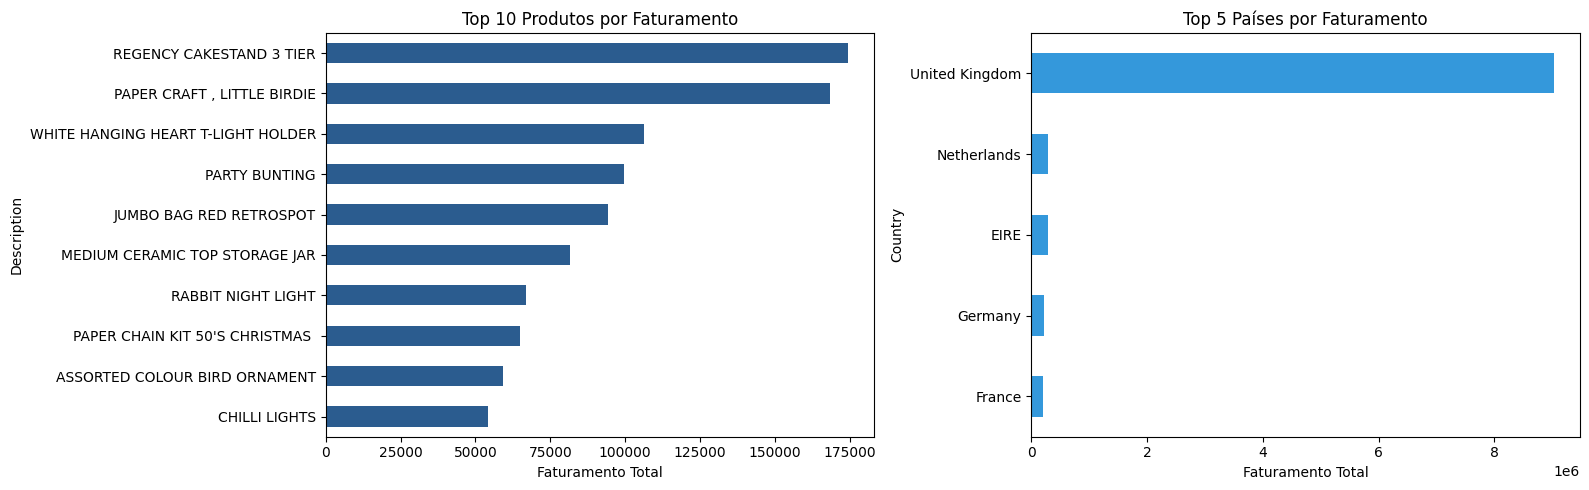

In [16]:
plt.style.use('seaborn-v8-whitegrid' if 'seaborn-v8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1 Filtrar taxas e fretes para considerar apenas produtos
taxas = ['DOTCOM POSTAGE', 'POSTAGE', 'Manual', 'PADS', 'POST']
df_produtos = df_clean[~df_clean['Description'].isin(taxas)]

# 2 Top 10 Produtos por Faturamento (sem taxas)
top_products = df_produtos.groupby('Description')['TotalSales'].sum().nlargest(10)
top_products.plot(kind='barh', ax=axes[0], color='#2b5c8f')
axes[0].set_title('Top 10 Produtos por Faturamento')
axes[0].set_xlabel('Faturamento Total')
axes[0].invert_yaxis()

# 3 Top 5 Países por Faturamento Gráfico de Barras
top_countries = df_clean.groupby('Country')['TotalSales'].sum().nlargest(5)
top_countries.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Top 5 Países por Faturamento')
axes[1].set_xlabel('Faturamento Total')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [12]:
# Agrupar os dados por dia, produto e país (reduz drasticamente o tamanho do arquivo mantendo todos os números exatos)
df_grouped = df_clean.groupby(['InvoiceDate', 'Country', 'Description', 'StockCode'], as_index=False).agg({
    'Quantity': 'sum',
    'TotalSales': 'sum',
    'Invoice': 'nunique'
})

# Exportar o arquivo compactado/agrupado (ficará com menos de 5MB)
df_grouped.to_csv('supermarket_data_agrupado.csv', index=False, encoding='utf-8')

from google.colab import files
files.download('supermarket_data_agrupado.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Exportar a base tratada para CSV
df_clean.to_csv('supermarket_data_clean.csv', index=False)

# Baixa o arquivo no computador para usar no Looker Studio
from google.colab import files
files.download('supermarket_data_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusão e Insights
* Dominância Local: O Reino Unido representa quase 90% das vendas, mostrando alta dependência de um único mercado geográfico.

* Produtos Chave: Uma fatia expressiva da receita vem de itens decorativos e utilidades domésticas, com destaque para o Regency Cakestand 3 Tier.

* Recomendações: Criar campanhas de incentivo à exportação/vendas internacionais para diversificar a receita e otimizar o estoque dos 10 produtos de maior faturamento para evitar rupturas.